# Markowitz on the NIFTY Universe

Aim - To apply the long-only Markowitz framework to the **49-asset NIFTY universe** under a strict **no-lookahead walk-forward** protocol (88 monthly rebalances, 2014–2021), compare four portfolio methods (equal-weight, min-var, capped MVO, target-risk SOCP) on out-of-sample return/Sharpe/turnover/drawdown, then add an **at-most-$K$ MIQP** for cardinality-constrained allocation against a greedy heuristic.

Also refer to [README](README.md).


## Setup

**Dataset.** `data/processed/price_matrix_full.csv` — 49 investable NIFTY assets, 2010-11-04 to 2021-04-30 (≈ 2,598 daily price rows). The `NIFTY50_all` index-duplicate column is dropped.

**Optimisation form.** All convex problems use

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \, \mu^\top w$$

with $\gamma = 5$ as the default return-emphasis scalar. Larger $\gamma$ tilts toward expected return; $\gamma \to 0$ gives the global minimum-variance portfolio. Equivalent risk-aversion form $\max_w \mu^\top w - \tilde\gamma w^\top \Sigma w$ maps via $\gamma = 1/(2\tilde\gamma)$.

**Requires SCIP** for the cardinality study (`pip install pyscipopt`). Convex sections run on CLARABEL.

In [1]:
from __future__ import annotations
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cvxpy as cp

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH   = REPO_ROOT / "data" / "processed" / "price_matrix_full.csv"
RESULTS_DIR = REPO_ROOT / "1_classical_baseline" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Data Construction

`price_matrix_full.csv` is a wide price panel produced by `data/Data_Pipeline.ipynb` from raw NSE OHLC data. The pipeline drops assets that delisted during the sample period and the index-level `NIFTY50_all` column, leaving 49 investable names.

Returns are raw daily percentage changes: $r_{i,t} = P_{i,t}/P_{i,t-1} - 1$.

**Unadjusted corporate actions.** The price matrix has not been adjusted for splits or bonus issues. 26 daily observations satisfy $|r_{i,t}| > 0.5$ — all known splits/bonuses (e.g. TITAN 4292 → 229, JSWSTEEL 1644 → 163), not real economic returns. These are masked to NaN so they do not corrupt EWMA $\hat\mu$ estimates:

$$r_{i,t} \leftarrow \begin{cases} \text{NaN} & |r_{i,t}| > 0.5 \\ r_{i,t} & \text{otherwise.} \end{cases}$$

No other preprocessing beyond `pct_change()`.

In [2]:
prices = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True).sort_index()
prices = prices.drop(columns=["NIFTY50_all"], errors="ignore")
asset_names = list(prices.columns)
n_assets    = len(asset_names)

ret_df = prices.pct_change()
# 26 observations with |r| > 0.5 are unadjusted corporate actions
ret_df = ret_df.where(ret_df.abs() < 0.5)
ret_df = ret_df.dropna(how="all")
dates  = ret_df.index

print(f"Universe  : {n_assets} assets")
print(f"Price span: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Return obs: {len(ret_df)} trading days")
print(f"SCIP available: {'SCIP' in cp.installed_solvers()}")

Universe  : 49 assets
Price span: 2010-11-04 → 2021-04-30
Return obs: 2597 trading days
SCIP available: True


## No-Lookahead Walk-Forward Protocol

At each rebalance date $t$ all estimators use only returns strictly before $t$:

$$\hat\mu_t, \, \hat\Sigma_t = f(\{r_s : s < t\}).$$

Portfolio weights $w_t$ are held over the next period $(t, t_{\text{next}}]$:

$$r^{\text{port}}_\tau = w_t^\top r_\tau, \qquad \tau \in (t, t_{\text{next}}].$$

The OOS block for window $i$ starts on the first trading day after $t_i$ and ends on (and including) $t_{i+1}$. The rebalance date itself is never measured.

**Cadence.** Last trading day of each month. **Test period:** 2014-01-01 to 2021-04-30 → 88 windows. **Training window:** trailing 756 trading days (≈ 3 years). Assets with fewer than 504 live observations in the trailing window are excluded from that rebalance.

**Performance metrics** computed from the full concatenated daily OOS series, not by averaging per-window:

$$\text{AnnReturn} = 252\,\bar r^{\text{daily}}, \quad \text{AnnVol} = \sqrt{252}\,\hat\sigma^{\text{daily}}, \quad \text{Sharpe} = \frac{\text{AnnReturn}}{\text{AnnVol}}.$$

In [3]:
GAMMA       = 5.0
MAX_POS     = 0.20
TRAIN_LEN   = 756          # trailing training days (~3 years)
TRAIN_DAYS  = 504          # minimum live observations in trailing window
TEST_START  = pd.Timestamp("2014-01-01")
TEST_END    = pd.Timestamp("2021-04-30")

SOLVER_OK = {"optimal", "optimal_inaccurate"}

In [4]:
def month_end_rebalances(index, test_start=TEST_START, test_end=TEST_END):
    # last trading day of each month in [test_start, test_end)
    start = test_start - pd.DateOffset(days=7)
    idx   = index[(index >= start) & (index <= test_end)]
    me    = pd.Series(idx, index=idx).groupby(idx.to_period("M")).max()
    rebal = pd.DatetimeIndex(me.values)
    return rebal[rebal < test_end]


rebal_dates = month_end_rebalances(dates)
print(f"Rebalance dates: {len(rebal_dates)} ({rebal_dates[0].date()} → {rebal_dates[-1].date()})")

Rebalance dates: 88 (2013-12-31 → 2021-03-31)


EWMA $\hat\mu$ (halflife 252) and sample $\hat\Sigma$ on the trailing 756 days. EWMA weights recent observations more heavily — appropriate for non-stationary return signals; sample $\hat\Sigma$ is acceptable because volatilities and correlations move slower than means.

In [5]:
def estimate_inputs_ewma(ret_df_full, tickers, rebal_date):
    # EWMA μ̂ + sample Σ̂ on trailing TRAIN_LEN days strictly before rebal_date
    r = ret_df_full[tickers].loc[:rebal_date].iloc[:-1].tail(TRAIN_LEN)
    mu_v  = r.ewm(halflife=252, min_periods=60).mean().iloc[-1].fillna(0.0).values * 252
    Sig_v = r.cov().fillna(0.0).values * 252
    return mu_v, Sig_v

## Portfolio Methods

Four methods share the universe, calendar, training window, and availability filter. They differ only in how $w_t$ is chosen.

### Equal-weight benchmark

$$w_i = \tfrac1n, \quad i = 1, \ldots, n.$$

No estimation. Any optimisation method that fails to beat equal-weight on OOS Sharpe is not adding value.

In [6]:
def solve_equal(n):
    return np.full(n, 1.0 / n)

### Minimum-variance portfolio

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0.$$

Ignores $\hat\mu$ entirely. Since $\hat\mu$ estimation is the dominant source of in-sample overfit in MVO, this gives an upper bound on the benefit of incorporating return signals.

In [7]:
def solve_min_var_portfolio(Sig_v):
    n = Sig_v.shape[0]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sig_v))),
        [cp.sum(w) == 1, w >= 0],
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    if prob.status not in SOLVER_OK or w.value is None:
        raise RuntimeError(f"min_var solver failed: {prob.status}")
    return np.asarray(w.value)

### Capped MVO

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; 0 \le w_i \le 0.20.$$

The 20% per-asset cap is enforced as a hard constraint inside the QP. This is the long-only utility form from `02_solvers.ipynb` plus a concentration cap.

In [8]:
def solve_long_only_capped(mu_v, Sig_v, gamma=GAMMA, cap=MAX_POS):
    n = mu_v.shape[0]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w, cp.psd_wrap(Sig_v)) - gamma * (mu_v @ w)),
        [cp.sum(w) == 1, w >= 0, w <= cap],
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    if prob.status not in SOLVER_OK or w.value is None:
        raise RuntimeError(f"capped MVO solver failed: {prob.status}")
    return np.asarray(w.value)

### Target-risk SOCP

$$\max_w \; \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; 0 \le w_i \le 0.20, \;\; \|L^\top w\|_2 \le \sigma_\star.$$

$L$ is the Cholesky factor of $\hat\Sigma$. $\sigma_\star$ is set per window to the in-sample portfolio volatility of the capped MVO solution, so both methods face the same risk budget — only the objective differs.

In [9]:
def solve_socp(mu_v, Sig_v, sigma_target, cap=MAX_POS):
    n = mu_v.shape[0]
    L = np.linalg.cholesky(Sig_v + 1e-8 * np.eye(n))
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Maximize(mu_v @ w),
        [cp.sum(w) == 1, w >= 0, w <= cap, cp.norm(L.T @ w, 2) <= sigma_target],
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    if prob.status not in SOLVER_OK or w.value is None:
        raise RuntimeError(f"SOCP solver failed: {prob.status}")
    return np.asarray(w.value)

## Walk-Forward Driver

Generic loop: pick a `weight_fn`, run across all rebalance dates, concatenate OOS daily returns, compute performance + turnover + drawdown. The driver handles the universe filter (assets with fewer than 504 live observations in the trailing window are excluded that rebalance).

**Turnover.** One-way per-rebalance: $\text{to}_t = \tfrac12 \sum_i |w_{i,t} - w_{i,t-1}|$. Diagnostic only; no transaction cost is charged.

**Drawdown.** Cumulative equity $V_t = \prod_{s \le t}(1 + r^{\text{port}}_s)$; underwater $\text{dd}_t = V_t / \max_{s \le t} V_s - 1$; max drawdown $\text{MDD} = \min_t \text{dd}_t$.

In [10]:
def compute_turnover(weights_list):
    W = np.array(weights_list)
    if len(W) < 2:
        return np.array([0.0])
    return 0.5 * np.abs(np.diff(W, axis=0)).sum(axis=1)


def compute_drawdown(daily_series):
    equity = (1.0 + daily_series).cumprod()
    peak   = np.maximum.accumulate(equity)
    return equity / peak - 1.0


def performance_summary(daily_series, label=""):
    ann_ret = 252.0 * daily_series.mean()
    ann_vol = np.sqrt(252.0) * daily_series.std(ddof=1)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else float("nan")
    return {"method": label, "OOS_return": ann_ret, "OOS_vol": ann_vol, "OOS_sharpe": sharpe}

The driver below is the only "big" cell in the notebook — splitting it would force every method to duplicate the universe-filter / OOS-block / accumulation logic.

In [11]:
def run_walkforward(weight_fn, label, tickers, ret_df_full,
                    rebal_dates_seq=None, gamma=GAMMA, cap=MAX_POS,
                    use_ewma=True, train_days_filter=True):
    if rebal_dates_seq is None:
        rebal_dates_seq = rebal_dates

    n_full = len(tickers)
    daily_pieces, weights_log, oos_start_log = [], [], []
    solve_times = []
    n_rebalances = 0

    for i, rdate in enumerate(rebal_dates_seq):
        r_tr      = ret_df_full[tickers].loc[:rdate].iloc[:-1]
        win_start = rdate - pd.DateOffset(years=3)
        if train_days_filter:
            avail = [t for t in tickers if r_tr[t].loc[win_start:].notna().sum() >= TRAIN_DAYS]
        else:
            avail = tickers
        if len(avail) < 2:
            continue

        avail_idx = np.array([tickers.index(t) for t in avail])
        n_a = len(avail)
        mu_v, Sig_v = estimate_inputs_ewma(ret_df_full, avail, rdate) if use_ewma \
                      else (None, ret_df_full[avail].loc[:rdate].iloc[:-1].tail(TRAIN_LEN).cov().values * 252)

        t0 = time.perf_counter()
        w_local = weight_fn(mu_v, Sig_v, n_a, avail_idx, rdate)
        solve_times.append(time.perf_counter() - t0)
        w_full  = np.zeros(n_full)
        w_full[avail_idx] = w_local

        # OOS block strictly after rdate
        next_date = rebal_dates_seq[i + 1] if i + 1 < len(rebal_dates_seq) else TEST_END
        window    = ret_df_full[tickers].loc[rdate:next_date].iloc[1:]
        if window.empty:
            continue
        oos_start_log.append(window.index[0])
        daily_pieces.append(pd.Series(window.fillna(0.0).values @ w_full, index=window.index))
        weights_log.append(w_full)
        n_rebalances += 1

    daily   = pd.concat(daily_pieces).sort_index() if daily_pieces else pd.Series(dtype=float)
    perf    = performance_summary(daily, label)
    to_arr  = compute_turnover(weights_log)
    dd_arr  = compute_drawdown(daily.values if not daily.empty else np.array([0.0]))
    equity  = (1.0 + daily).cumprod() if not daily.empty else pd.Series(dtype=float)
    drawdown = pd.Series(dd_arr, index=daily.index) if not daily.empty else pd.Series(dtype=float)
    last_w  = weights_log[-1] if weights_log else np.zeros(n_full)
    perf.update({
        "avg_turnover":      float(to_arr.mean()) if to_arr.size else 0.0,
        "median_turnover":   float(np.median(to_arr)) if to_arr.size else 0.0,
        "max_drawdown":      float(dd_arr.min()) if len(dd_arr) else 0.0,
        "n_rebalances":      n_rebalances,
        "mean_solve_s":      float(np.mean(solve_times)) if solve_times else 0.0,
        "n_active_holdings": int((last_w > 1e-5).sum()),
        "max_weight":        float(last_w.max()),
    })
    return perf, daily, equity, drawdown, np.array(oos_start_log)

## Run Walk-Forward — Four Methods

The target-risk SOCP needs a per-window $\sigma_\star$ equal to the capped MVO's in-sample volatility. Compute that map first, then run all four methods through the same driver.

In [12]:
lo_sigma_map = {}
for rdate in rebal_dates:
    r_tr     = ret_df[asset_names].loc[:rdate].iloc[:-1]
    win_start = rdate - pd.DateOffset(years=3)
    avail     = [t for t in asset_names if r_tr[t].loc[win_start:].notna().sum() >= TRAIN_DAYS]
    if len(avail) < 2:
        continue
    mu_v, Sig_v = estimate_inputs_ewma(ret_df, avail, rdate)
    try:
        w_cap = solve_long_only_capped(mu_v, Sig_v)
        lo_sigma_map[rdate] = float(np.sqrt(w_cap @ Sig_v @ w_cap))
    except RuntimeError:
        lo_sigma_map[rdate] = None

print(f"sigma targets computed for {sum(v is not None for v in lo_sigma_map.values())} windows")

sigma targets computed for 88 windows


In [13]:
def socp_weight_fn(mu_v, Sig_v, n_a, avail_idx, rdate):
    sigma_target = lo_sigma_map.get(rdate)
    if sigma_target is None:
        return solve_equal(n_a)
    return solve_socp(mu_v, Sig_v, sigma_target)


methods_config = {
    "equal_weight":      lambda mu, Sig, n, idx, d: solve_equal(n),
    "min_var_portfolio": lambda mu, Sig, n, idx, d: solve_min_var_portfolio(Sig),
    "capped_MVO":        lambda mu, Sig, n, idx, d: solve_long_only_capped(mu, Sig),
    "target_risk_SOCP":  socp_weight_fn,
}

In [14]:
perf_rows       = []
equity_curves   = {}
drawdown_curves = {}
daily_oos       = {}

for name, wfn in methods_config.items():
    print(f"running {name}", flush=True)
    perf, daily, equity, dd, _ = run_walkforward(
        weight_fn=wfn, label=name, tickers=asset_names, ret_df_full=ret_df,
    )
    perf_rows.append(perf)
    equity_curves[name]   = equity
    drawdown_curves[name] = dd
    daily_oos[name]       = daily

df_oos = pd.DataFrame(perf_rows)
df_oos.to_csv(RESULTS_DIR / "oos_walkforward.csv", index=False)
display(df_oos[["method", "OOS_sharpe", "OOS_return", "OOS_vol",
                "avg_turnover", "max_drawdown", "n_rebalances"]].round(4))

running equal_weight
running min_var_portfolio
running capped_MVO
running target_risk_SOCP


,method,OOS_sharpe,OOS_return,OOS_vol,avg_turnover,max_drawdown,n_rebalances
0,equal_weight,0.9795,0.1741,0.1778,0.0000,-0.4127,88
1,min_var_portfolio,1.1228,0.1636,0.1457,0.0510,-0.3216,88
2,capped_MVO,1.1942,0.2699,0.2260,0.2029,-0.4035,88
3,target_risk_SOCP,1.1942,0.2699,0.2260,0.2029,-0.4035,88


## Cardinality-Constrained Allocation

A real investor may face an operational limit on the number of positions — custody, monitoring burden, fund-mandate cap. The at-most-$K$ constraint formalises this:

$$\sum_{i=1}^n y_i \le K, \quad y_i \in \{0, 1\}.$$

Now the problem is no longer convex. The set $\{0, 1\}^n$ is not convex, so the convex relaxation has a strictly larger feasible set and gives a lower bound on the integer optimum. Closing the gap requires branch-and-bound or another exact enumeration scheme.

### MIQP formulation

Let $y \in \{0, 1\}^n$ be selection indicators and $w \in \mathbb R^n$ portfolio weights:

$$\begin{aligned}
\min_{w, y} \quad & \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \\
\text{s.t.} \quad & \mathbf 1^\top w = 1, \\
& 0 \le w_i \le u \, y_i \;\;\forall i, \\
& \sum_{i=1}^n y_i \le K, \quad y_i \in \{0, 1\}.
\end{aligned}$$

The bound $w_i \le u y_i$ forces $w_i = 0$ when $y_i = 0$ and caps $w_i \le u$ when $y_i = 1$.

**Feasibility condition.** Full investment requires at least $\lceil 1/u \rceil$ selected assets. With $u = 0.20$: $K \cdot u \ge 1 \Rightarrow K \ge 5$. The K-sweep below uses $K \in \{5, 7, 10, 15, 20\}$.

In [15]:
def solve_miqp(mu_v, Sig_v, k, gamma=GAMMA, cap=MAX_POS):
    # at-most-K MIQP via SCIP; returns (weights, y_binary, elapsed)
    n = mu_v.shape[0]
    w = cp.Variable(n)
    y = cp.Variable(n, boolean=True)
    prob = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w, cp.psd_wrap(Sig_v)) - gamma * (mu_v @ w)),
        [cp.sum(w) == 1, w >= 0, w <= cap * y, cp.sum(y) <= k],
    )
    t0 = time.perf_counter()
    prob.solve(solver=cp.SCIP)
    elapsed = time.perf_counter() - t0
    if prob.status not in SOLVER_OK or w.value is None:
        raise RuntimeError(f"MIQP solver failed: {prob.status}")
    return np.asarray(w.value), np.asarray(y.value).round().astype(int), elapsed

### Greedy heuristic

Pick the $K$ assets with the highest in-sample Sharpe $\hat\mu_i / \hat\sigma_i$, then re-solve the capped MVO on that subset:

$$S = \mathrm{argtop}_K \frac{\hat\mu_i}{\hat\sigma_i}, \qquad \text{then MVO on } S.$$

The greedy solution is always a feasible MIQP point — the MIQP objective is no worse than greedy. But on OOS Sharpe the ranking is not guaranteed because Sharpe is not the optimised objective.

In [16]:
def solve_greedy_screen(mu_v, Sig_v, n_full, k, gamma=GAMMA, cap=MAX_POS):
    vol   = np.sqrt(np.clip(np.diag(Sig_v), 1e-12, None))
    score = mu_v / vol
    top   = np.argsort(-score)[:k]
    w_sub = cp.Variable(k)
    prob  = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w_sub, cp.psd_wrap(Sig_v[np.ix_(top, top)]))
                    - gamma * (mu_v[top] @ w_sub)),
        [cp.sum(w_sub) == 1, w_sub >= 0, w_sub <= cap],
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)
    w_full = np.zeros(n_full)
    if prob.status in SOLVER_OK and w_sub.value is not None:
        w_full[top] = np.asarray(w_sub.value)
    else:
        w_full[top] = 1.0 / k
    return w_full, top

### In-sample comparison at $K = 10$

Run MIQP, the continuous relaxation (capped MVO without cardinality, which is a lower bound on the MIQP objective), and greedy on the full-history $\hat\mu$, $\hat\Sigma$.

In [17]:
K_INSAMPLE = 10

mu_is  = 252.0 * ret_df.mean(axis=0).fillna(0.0).values
Sig_is = 252.0 * ret_df.cov().fillna(0.0).values


def report_insample(label, w, elapsed, y=None):
    ret_  = float(mu_is @ w)
    vol_  = float(np.sqrt(w @ Sig_is @ w))
    n_sel = int((w > 1e-5).sum())
    n_y   = int(y.sum()) if y is not None else n_sel
    return {
        "method":            label,
        "solve_time_s":      elapsed,
        "n_selected_y":      n_y,
        "n_active_holdings": n_sel,
        "in_sample_return":  ret_,
        "in_sample_vol":     vol_,
        "in_sample_sharpe":  ret_ / vol_ if vol_ > 0 else float("nan"),
        "max_weight":        float(w.max()),
    }

In [18]:
rows_is = []

print("solving MIQP (SCIP)", flush=True)
w_miqp, y_miqp, t_miqp = solve_miqp(mu_is, Sig_is, K_INSAMPLE)
rows_is.append(report_insample(f"MIQP K<={K_INSAMPLE}", w_miqp, t_miqp, y_miqp))

print("solving convex relaxation (no cardinality)", flush=True)
t0 = time.perf_counter()
w_relax = solve_long_only_capped(mu_is, Sig_is, cap=MAX_POS)
t_relax = time.perf_counter() - t0
rows_is.append(report_insample("convex relaxation", w_relax, t_relax))

print(f"solving greedy top-{K_INSAMPLE}", flush=True)
t0 = time.perf_counter()
w_greedy_is, _ = solve_greedy_screen(mu_is, Sig_is, n_assets, K_INSAMPLE)
t_greedy_is = time.perf_counter() - t0
y_greedy_is = (w_greedy_is > 1e-8).astype(float)
rows_is.append(report_insample(f"greedy top-{K_INSAMPLE}", w_greedy_is, t_greedy_is, y_greedy_is))

comp_is = pd.DataFrame(rows_is)
comp_is.to_csv(RESULTS_DIR / "miqp_comparison.csv", index=False)
display(comp_is[["method", "n_selected_y", "n_active_holdings",
                 "in_sample_sharpe", "max_weight", "solve_time_s"]].round(4))

solving MIQP (SCIP)
solving convex relaxation (no cardinality)
solving greedy top-10


,method,n_selected_y,n_active_holdings,in_sample_sharpe,max_weight,solve_time_s
0,MIQP K<=10,7,6,1.5692,0.2,0.1501
1,convex relaxation,6,6,1.5691,0.2,0.0081
2,greedy top-10,6,6,1.5691,0.2,0.0065


### $K$ sweep

Sweeping $K$ shows where the cardinality constraint becomes binding. At large $K$ relative to the universe, the convex relaxation already concentrates in fewer than $K$ assets, so the MIQP cap is not binding and the two methods converge. At small $K$ the constraint forces the MIQP to choose fewer assets than the relaxation would prefer, opening a gap.

In [19]:
K_GRID = [5, 7, 10, 15, 20]

sweep_rows = []
for k in K_GRID:
    print(f"  K={k}", end=" ", flush=True)
    w_m, y_m, t_m = solve_miqp(mu_is, Sig_is, k)
    sweep_rows.append({
        "K": k, "method": f"MIQP K<={k}",
        "n_selected_y":     int(y_m.sum()),
        "n_active_holdings": int((w_m > 1e-5).sum()),
        "in_sample_return": float(mu_is @ w_m),
        "in_sample_vol":    float(np.sqrt(w_m @ Sig_is @ w_m)),
        "in_sample_sharpe": float(mu_is @ w_m) / float(np.sqrt(w_m @ Sig_is @ w_m)),
        "solve_time_s":     t_m,
    })

    w_g, _ = solve_greedy_screen(mu_is, Sig_is, n_assets, k)
    sweep_rows.append({
        "K": k, "method": f"greedy top-{k}",
        "n_selected_y":     k,
        "n_active_holdings": int((w_g > 1e-5).sum()),
        "in_sample_return": float(mu_is @ w_g),
        "in_sample_vol":    float(np.sqrt(w_g @ Sig_is @ w_g)),
        "in_sample_sharpe": float(mu_is @ w_g) / float(np.sqrt(w_g @ Sig_is @ w_g)),
        "solve_time_s":     float("nan"),
    })
    print("done")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(RESULTS_DIR / "miqp_K_sweep.csv", index=False)
display(sweep_df[["K", "method", "n_active_holdings", "in_sample_sharpe", "solve_time_s"]].round(4))

  K=5 done
  K=7 done
  K=10 done
  K=15 done
  K=20 done


,K,method,n_active_holdings,in_sample_sharpe,solve_time_s
0,5,MIQP K<=5,5,1.5605,0.0789
1,5,greedy top-5,5,1.5545,NaN
2,7,MIQP K<=7,6,1.5691,0.1343
3,7,greedy top-7,5,1.6062,NaN
4,10,MIQP K<=10,6,1.5692,0.1456
5,10,greedy top-10,6,1.5691,NaN
6,15,MIQP K<=15,6,1.5692,0.1483
7,15,greedy top-15,6,1.5692,NaN
8,20,MIQP K<=20,6,1.5692,0.1442
9,20,greedy top-20,6,1.5692,NaN


### Walk-forward MIQP vs greedy at $K = 10$

The in-sample comparison fixes the input data. The walk-forward comparison tests whether the MIQP's edge over greedy survives real estimation uncertainty across 88 out-of-sample windows.

In [20]:
K_WF = 10
times_miqp, times_greedy = [], []
daily_miqp_list, daily_greedy_list = [], []
weights_miqp_log, weights_greedy_log = [], []

print(f"walk-forward MIQP vs greedy (K={K_WF}, {len(rebal_dates)} windows)", flush=True)

for i, rdate in enumerate(rebal_dates):
    r_tr      = ret_df[asset_names].loc[:rdate].iloc[:-1]
    win_start = rdate - pd.DateOffset(years=3)
    avail     = [t for t in asset_names if r_tr[t].loc[win_start:].notna().sum() >= TRAIN_DAYS]
    if len(avail) < K_WF:
        continue
    avail_idx = np.array([asset_names.index(t) for t in avail])
    n_a       = len(avail)
    mu_v, Sig_v = estimate_inputs_ewma(ret_df, avail, rdate)

    t0 = time.perf_counter()
    w_g_local, _ = solve_greedy_screen(mu_v, Sig_v, n_a, K_WF)
    times_greedy.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    w_m_local, _, _ = solve_miqp(mu_v, Sig_v, K_WF)
    times_miqp.append(time.perf_counter() - t0)

    w_g_full = np.zeros(n_assets); w_g_full[avail_idx] = w_g_local
    w_m_full = np.zeros(n_assets); w_m_full[avail_idx] = w_m_local

    next_date = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else TEST_END
    window    = ret_df[asset_names].loc[rdate:next_date].iloc[1:]
    if window.empty:
        continue
    r_arr = window.fillna(0.0).values
    daily_greedy_list.append(pd.Series(r_arr @ w_g_full, index=window.index))
    daily_miqp_list.append(pd.Series(r_arr @ w_m_full, index=window.index))
    weights_greedy_log.append(w_g_full)
    weights_miqp_log.append(w_m_full)

walk-forward MIQP vs greedy (K=10, 88 windows)


In [21]:
wf_rows = []
for label, daily_list, times, w_log in [
    (f"greedy K={K_WF}", daily_greedy_list, times_greedy, weights_greedy_log),
    (f"MIQP K={K_WF}",   daily_miqp_list,   times_miqp,   weights_miqp_log),
]:
    daily  = pd.concat(daily_list).sort_index()
    perf   = performance_summary(daily, label)
    to_arr = compute_turnover(w_log)
    dd_arr = compute_drawdown(daily.values)
    last_w = w_log[-1]
    perf.update({
        "mean_solve_s":      float(np.mean(times)),
        "median_solve_s":    float(np.median(times)),
        "n_windows":         len(times),
        "avg_turnover":      float(to_arr.mean()) if to_arr.size else 0.0,
        "max_drawdown":      float(dd_arr.min()) if len(dd_arr) else 0.0,
        "n_active_holdings": int((last_w > 1e-5).sum()),
        "max_weight":        float(last_w.max()),
    })
    wf_rows.append(perf)

wf_df = pd.DataFrame(wf_rows)
wf_df.to_csv(RESULTS_DIR / "miqp_walkforward.csv", index=False)
display(wf_df[["method", "OOS_sharpe", "mean_solve_s", "n_windows"]].round(4))

,method,OOS_sharpe,mean_solve_s,n_windows
0,greedy K=10,1.2355,0.0059,88
1,MIQP K=10,1.1942,0.0630,88


Solve-time comparison on a log axis — MIQP is branch-and-bound, greedy is one capped-MVO QP per window.

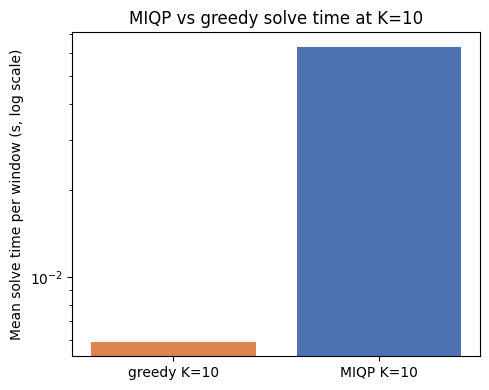

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
labels_bt  = [f"greedy K={K_WF}", f"MIQP K={K_WF}"]
mean_times = [wf_df.loc[wf_df["method"] == m, "mean_solve_s"].iloc[0] for m in labels_bt]
ax.bar(labels_bt, mean_times, color=["#dd8452", "#4c72b0"])
ax.set_yscale("log")
ax.set_ylabel("Mean solve time per window (s, log scale)")
ax.set_title(f"MIQP vs greedy solve time at K={K_WF}")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "miqp_walkforward_solvetime.png", dpi=120)
plt.show()

## Growth of $1 and Drawdown — All Six Strategies

Single two-panel plot covering every walk-forward strategy: top = value of \$1 invested at test start (2014-01-01) rolled month-to-month under each strategy's weights; bottom = underwater drawdown from running peak. X-axis pinned to the OOS test window. `capped_MVO` and `target_risk_SOCP` produce nearly identical portfolios (SOCP $\sigma_\star$ set per window to capped-MVO volatility) so SOCP uses a dashed line to show the overlap.

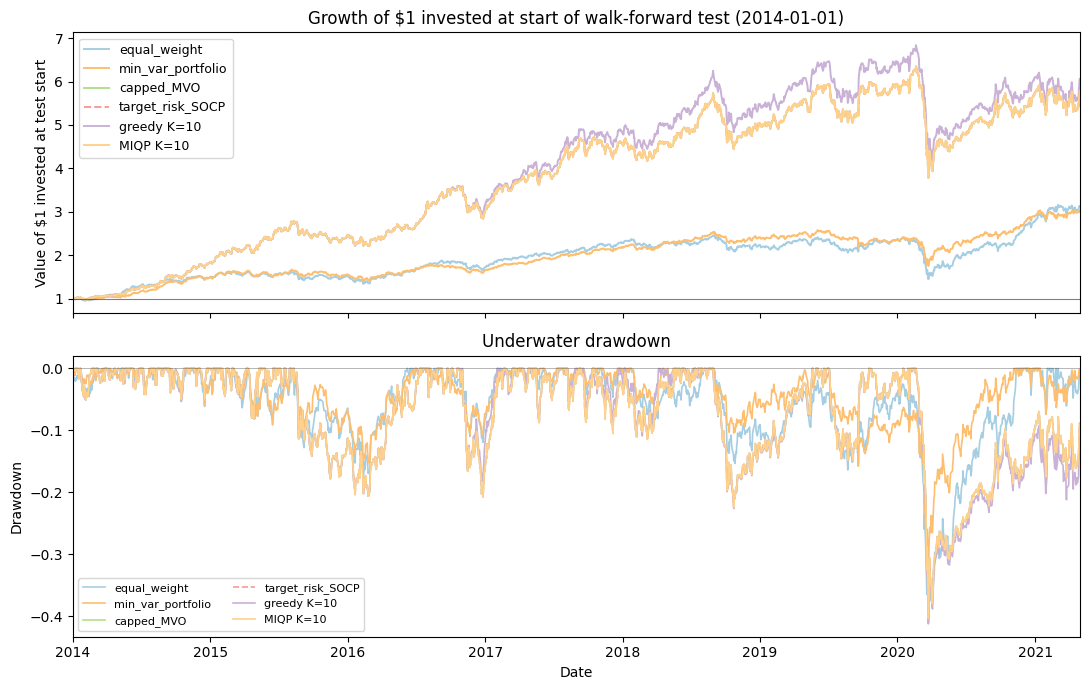

In [23]:
# Light pastel palette — Set2-derived, soft and distinct
colors     = {"equal_weight":      "#A6CEE3",   # light blue
              "min_var_portfolio": "#FDBF6F",   # light orange
              "capped_MVO":        "#B2DF8A",   # light green
              "target_risk_SOCP":  "#FB9A99"}   # light red
linestyles = {"equal_weight": "-", "min_var_portfolio": "-",
              "capped_MVO": "-", "target_risk_SOCP": "--"}

# build daily series for the two cardinality strategies
greedy_daily = pd.concat(daily_greedy_list).sort_index()
miqp_daily   = pd.concat(daily_miqp_list).sort_index()
extra = [
    (f"greedy K={K_WF}", greedy_daily, "#CAB2D6", "-"),   # light purple
    (f"MIQP K={K_WF}",   miqp_daily,   "#FFD18A", "-"),   # light peach
]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# top: $1 growth
for name in methods_config:
    if name not in equity_curves or equity_curves[name].empty:
        continue
    axes[0].plot(equity_curves[name].index, equity_curves[name].values,
                 color=colors[name], linestyle=linestyles[name], label=name, lw=1.4)
for label, daily_s, c, ls in extra:
    eq = (1.0 + daily_s).cumprod()
    axes[0].plot(eq.index, eq.values, color=c, linestyle=ls, lw=1.4, label=label)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.5)
axes[0].set_ylabel("Value of $1 invested at test start")
axes[0].set_title("Growth of $1 invested at start of walk-forward test (2014-01-01)")
axes[0].legend(fontsize=9, loc="upper left")

# bottom: drawdown
for name in methods_config:
    if name not in drawdown_curves or drawdown_curves[name].empty:
        continue
    axes[1].plot(drawdown_curves[name].index, drawdown_curves[name].values,
                 color=colors[name], linestyle=linestyles[name], lw=1.2, label=name)
for label, daily_s, c, ls in extra:
    dd = pd.Series(compute_drawdown(daily_s.values), index=daily_s.index)
    axes[1].plot(dd.index, dd.values, color=c, linestyle=ls, lw=1.2, label=label)
axes[1].axhline(0.0, color="black", lw=0.5, alpha=0.4)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_title("Underwater drawdown")
axes[1].legend(fontsize=8, loc="lower left", ncol=2)

axes[0].set_xlim(TEST_START, TEST_END)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "drawdown_paths.png", dpi=120)
plt.show()

## Summary

All walk-forward methods in one table. Six rows: 4 baseline methods from `df_oos` + 2 cardinality methods from `wf_df`. Every cell populated — `mean_solve_s` is the mean per-window weight-solver call time (excludes OOS application, which is one matmul per window). `n_active_holdings` and `max_weight` come from the final-window weights.

In [24]:
COLS = ["method", "OOS_sharpe", "OOS_return", "OOS_vol",
        "avg_turnover", "max_drawdown",
        "n_active_holdings", "max_weight", "mean_solve_s"]

summary_df = pd.concat([df_oos[COLS], wf_df[COLS]], ignore_index=True)
summary_df.to_csv(RESULTS_DIR / "summary_table.csv", index=False)
display(summary_df.round(4))

,method,OOS_sharpe,OOS_return,OOS_vol,avg_turnover,max_drawdown,n_active_holdings,max_weight,mean_solve_s
0,equal_weight,0.9795,0.1741,0.1778,0.0000,-0.4127,49,0.0204,0.0000
1,min_var_portfolio,1.1228,0.1636,0.1457,0.0510,-0.3216,18,0.1398,0.0065
2,capped_MVO,1.1942,0.2699,0.2260,0.2029,-0.4035,5,0.2000,0.0075
3,target_risk_SOCP,1.1942,0.2699,0.2260,0.2029,-0.4035,5,0.2000,0.0083
4,greedy K=10,1.2355,0.2760,0.2234,0.2097,-0.4114,5,0.2000,0.0059
5,MIQP K=10,1.1942,0.2699,0.2260,0.2029,-0.4035,5,0.2000,0.0630


## Interpretation

- **$\hat\mu$ added value here.** capped_MVO OOS Sharpe (1.194) beats min_var_portfolio (1.123) and equal_weight (0.980). The EWMA $\hat\mu$ signal survives its own estimation-error cost on this universe + window. Min-var still wins on max drawdown (-32% vs -40%) — accepting the return signal trades stability for return.
- **SOCP ≡ capped MVO.** Both hit the same Sharpe (1.194), same return (0.270), same volatility (0.226), same 5-name support, same 20% max weight, same turnover (0.20), same drawdown (-0.40). The SOCP's $\sigma_\star$ is set per window to capped MVO's volatility — by Lagrangian duality at the active risk constraint the two formulations land on the same portfolio. Confirmed empirically.
- **Greedy beats MIQP out-of-sample at $K = 10$.** In-sample MIQP wins by epsilon (1.5692 vs 1.5691). OOS the rank flips: greedy 1.2355, MIQP 1.1942. MIQP overfits to noisy $\hat\mu$ — it picks the integer combination that minimises in-sample utility, which doesn't generalise. Greedy's μ̂/σ̂ ranking is a coarser but more robust selector. MIQP also costs 11× more wall time (0.065 s vs 0.006 s per window). Use greedy unless an actual cardinality benefit appears.
- **Cardinality rarely binds at $K \ge 7$.** K-sweep: both MIQP and greedy converge to **6 active holdings** at every $K \ge 7$. The 20% per-asset cap forces the support out to ~5–6 names regardless of the $K$ limit. The cardinality constraint only matters at $K = 5$, where it forces an extra name beyond what the cap alone would select.
- **Drawdown trade-off.** All return-seeking methods (capped_MVO, SOCP, greedy, MIQP) bottom near -40% in March 2020. min_var caps at -32%. Equal-weight is worst at -41%. The minimum-variance objective genuinely buys drawdown insurance — at the cost of lower terminal Sharpe.

## Limitations

- **Frictionless backtest.** No transaction costs, turnover penalties, or market-impact model. OOS Sharpe is gross of friction. Turnover is reported but not penalised — capped_MVO and SOCP run 20% per-rebalance turnover which would meaningfully hit returns net of costs.
- **Survivorship-adjacent universe.** The 49-asset list is fixed at the start of the sample (Nov 2010). Assets that delisted between 2010 and 2021 are absent — mild survivorship bias upward in all OOS Sharpes.
- **Estimation noise drives the MIQP-vs-greedy result.** EWMA $\hat\mu$ and sample $\hat\Sigma$ are noisy. The OOS MIQP loss to greedy is a direct symptom of overfitting noisy $\hat\mu$ — shrinkage estimators (Ledoit-Wolf for $\hat\Sigma$, James-Stein for $\hat\mu$) would likely narrow the gap. Out of scope here.
- **Unadjusted corporate actions.** Source prices are unadjusted; 26 split/bonus days are masked to NaN. The correct long-term fix is to adjust at source in the data pipeline.
- **At-most-$K$, not exact-$K$.** At $K = 10$ with $u = 0.20$, the unconstrained solution already uses ~6 assets, so at-most-$K$ and exact-$K$ produce similar portfolios on this universe. They would diverge with a minimum-position-size constraint.
- **No shorting or leverage.** All formulations enforce $w \ge 0$ and $\mathbf 1^\top w = 1$.
- **SOCP redundancy on this universe.** SOCP gave zero new information because its $\sigma_\star$ matched the capped MVO solution exactly. Its value would emerge if $\sigma_\star$ were set independently (e.g. to a fund-mandate risk target) rather than tied to another method's output.